# Lab 05 – Image Segmentation (Tasks 1–10)
Only **Python, OpenCV and NumPy** are used (matplotlib is used just to display images). No segmentation library / deep-learning model.

Images are in the `Data/` folder, final outputs are saved in the `Output/` folder.

In [1]:
import cv2, os
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

os.makedirs('Output', exist_ok=True)

def read(name, gray=False):
    # cv2.imread(path, 0) loads grayscale, 1 loads color (BGR)
    return cv2.imread('Data/' + name, 0 if gray else 1)

def show(images, titles, save_as, cols=None, size=3.5):
    # shows images side by side and saves the figure in Output/
    cols = cols or len(images)
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(size * cols, size * rows * 1.1))
    for i, (img, t) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 3:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))   # OpenCV is BGR, matplotlib needs RGB
        else:
            plt.imshow(img, cmap='gray', vmin=0, vmax=255)
        plt.title(t, fontsize=9); plt.axis('off')
    plt.tight_layout()
    plt.savefig('Output/' + save_as, dpi=120)
    plt.show()

## Task 1 – Document under uneven lighting (Global vs Adaptive threshold)
Steps: load grayscale → 3 global thresholds → adaptive threshold → compare.

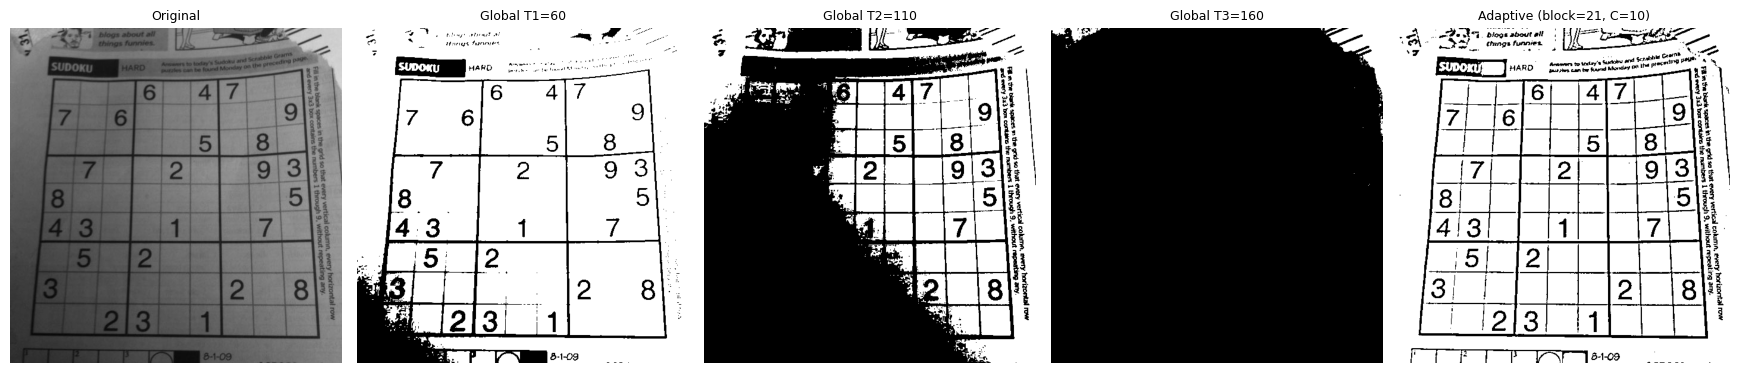

In [2]:
gray = read('sudoku.png', gray=True)

# Global thresholding: same threshold T for every pixel. pixel > T -> white(255), else black(0)
T1, T2, T3 = 60, 110, 160
g1 = cv2.threshold(gray, T1, 255, cv2.THRESH_BINARY)[1]
g2 = cv2.threshold(gray, T2, 255, cv2.THRESH_BINARY)[1]
g3 = cv2.threshold(gray, T3, 255, cv2.THRESH_BINARY)[1]

# Adaptive thresholding: threshold is calculated from the neighbourhood of every pixel
adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, 21, 10)

show([gray, g1, g2, g3, adaptive],
     ['Original', f'Global T1={T1}', f'Global T2={T2}', f'Global T3={T3}', 'Adaptive (block=21, C=10)'],
     'task1_result.png')

In [3]:
# Which regions make global thresholding fail? Compare left / middle / right part of the page.
h, w = gray.shape
parts = {'Left': slice(0, w // 3), 'Middle': slice(w // 3, 2 * w // 3), 'Right': slice(2 * w // 3, w)}

print(f"{'Region':8}{'mean brightness':>16}{'%black T1':>11}{'%black T2':>11}{'%black T3':>11}{'%black Adaptive':>17}")
for name, sl in parts.items():
    row = [gray[:, sl].mean()] + [(m[:, sl] == 0).mean() * 100 for m in (g1, g2, g3, adaptive)]
    print(f"{name:8}{row[0]:16.1f}{row[1]:11.1f}{row[2]:11.1f}{row[3]:11.1f}{row[4]:17.1f}")

Region   mean brightness  %black T1  %black T2  %black T3  %black Adaptive
Left                80.8       22.9       87.9       99.2             11.6
Middle              99.5       10.1       60.8      100.0             14.6
Right              125.1        5.6       23.1       96.0             15.7


**Parameters used:** global T = 60 / 110 / 160 (dark, medium, bright guesses); adaptive = Gaussian, blockSize 21 (about the size of a digit so the local average sees text + paper), C = 10 (ignores paper texture but keeps thin text).

### Answer – why does a single threshold struggle when illumination changes across the image?
A global threshold uses **one** brightness value for every pixel. But the page is darker on the left (mean ≈ 81) than on the right (mean ≈ 125), so the *paper* on the left is as dark as the *ink* on the right.
* **T1 = 60:** keeps the right/middle fine but loses the faint text and ink in the top-left, and the dark bottom-left corner turns black.
* **T2 = 110:** the whole dark left side (87.9 % black) becomes background-black and swallows the text.
* **T3 = 160:** everything is below 160 → page becomes completely black.
* **Failing regions:** the dark **left side**, the **bottom-left corner** and the **top** of the page (shadow / newspaper pictures).
* **Adaptive (Gaussian, 21, 10):** the threshold is computed from each pixel's neighbourhood, so it follows the lighting; black pixels are about 12–16 % in all three parts of the page and the digits are readable everywhere. **Best result = adaptive** (best global ≈ T1 = 60, but still loses text in the dark areas).

## Task 2 – Adaptive threshold: blockSize and C
`blockSize` = size of the local neighbourhood, `C` = constant subtracted from the local mean (pixel is white if pixel > local_mean − C).

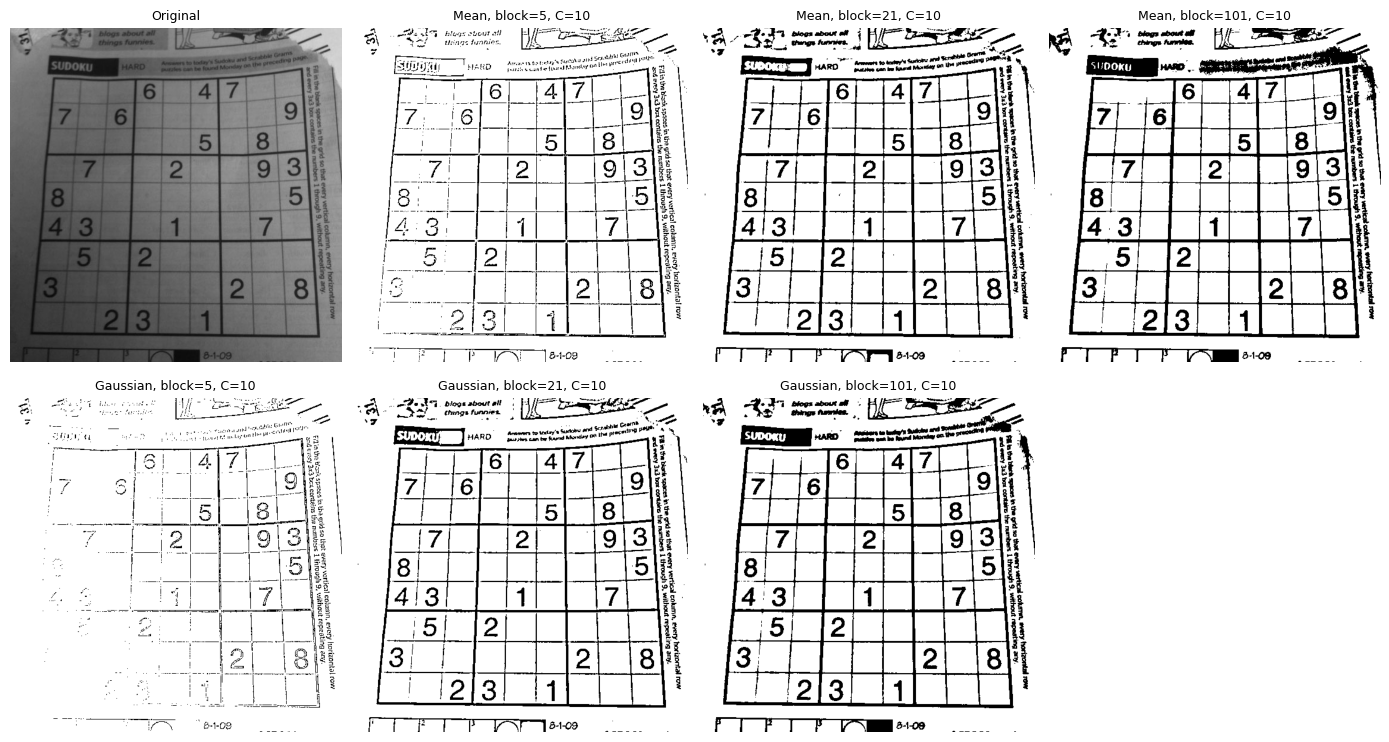

In [4]:
gray = read('sudoku.png', gray=True)
methods = {'Mean': cv2.ADAPTIVE_THRESH_MEAN_C, 'Gaussian': cv2.ADAPTIVE_THRESH_GAUSSIAN_C}

# A) both methods x 3 blockSizes (C fixed = 10)
imgs, titles = [gray], ['Original']
for mname, m in methods.items():
    for bs in [5, 21, 101]:
        imgs.append(cv2.adaptiveThreshold(gray, 255, m, cv2.THRESH_BINARY, bs, 10))
        titles.append(f'{mname}, block={bs}, C=10')
show(imgs, titles, 'task2_blocksize.png', cols=4)

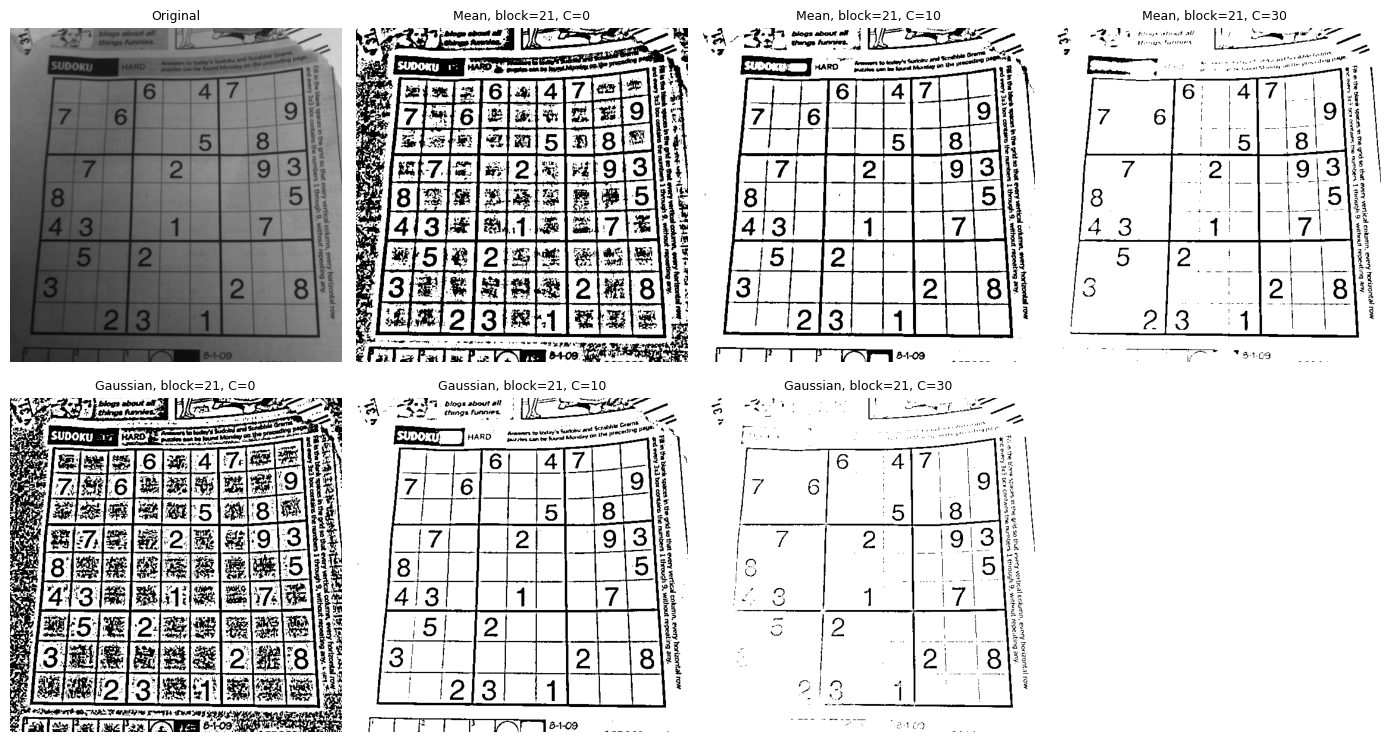

In [5]:
# B) 3 C values (blockSize fixed = 21), both methods
imgs, titles = [gray], ['Original']
for mname, m in methods.items():
    for C in [0, 10, 30]:
        imgs.append(cv2.adaptiveThreshold(gray, 255, m, cv2.THRESH_BINARY, 21, C))
        titles.append(f'{mname}, block=21, C={C}')
show(imgs, titles, 'task2_C.png', cols=4)

In [6]:
# Parameter comparison table: % of black pixels (text + noise) for every combination
print(f"{'Method':10}{'block':>6}{'C':>4}{'% black':>9}")
for mname, m in methods.items():
    for bs in [5, 21, 101]:
        for C in [0, 10, 30]:
            out = cv2.adaptiveThreshold(gray, 255, m, cv2.THRESH_BINARY, bs, C)
            print(f"{mname:10}{bs:6}{C:4}{(out == 0).mean() * 100:9.1f}")

Method     block   C  % black
Mean           5   0     54.2
Mean           5  10      9.3
Mean           5  30      0.6
Mean          21   0     36.8
Mean          21  10     16.6
Mean          21  30      8.6
Mean         101   0     27.2
Mean         101  10     18.9
Mean         101  30     10.9
Gaussian       5   0     60.0
Gaussian       5  10      4.9
Gaussian       5  30      0.1
Gaussian      21   0     41.2
Gaussian      21  10     14.0
Gaussian      21  30      5.6
Gaussian     101   0     27.8
Gaussian     101  10     17.8
Gaussian     101  30     10.0


### Task 2 analysis

1. **Neighbourhood too small (block = 5):** the local average is almost the pixel itself, so only the thin edges of strokes survive. Digits become hollow / broken (see Gaussian block=5) – broken characters.
2. **Neighbourhood too large (block = 101):** the local average covers big areas, so it behaves like a global threshold again. Thick dark blobs appear near the dark page corner / top-right text, and the lighting problem partly returns.
3. **C increased:** the threshold becomes `local mean − C`, so fewer pixels turn black. C = 0 → lots of black noise inside and around the digits (up to ~41 % black). C = 10 → clean. C = 30 → noise gone, but thin lines and some digits fade away (only ~6 % black).
4. **Cleanest combination:** blockSize 21, C = 10 (Gaussian) – complete digits and grid, clean white paper.
5. **Better method:** Gaussian was slightly better – it weights the centre pixels more, so it gives smoother thresholds and fewer broken thin lines than the plain mean (e.g. block=5 differences, fewer blobs at block=101).

## Task 3 – Otsu's thresholding (automatic threshold)

Otsu threshold selected automatically: 162.0


C:\Users\DELL\AppData\Local\Temp\ipykernel_18828\2117123210.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(1, 3, 2); plt.hist(gray.ravel(), 256, [0, 256], color='gray')


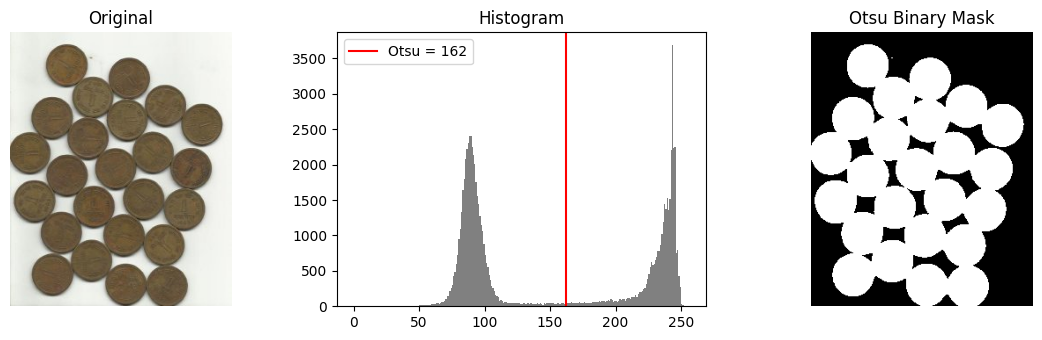

In [7]:
img = read('coins.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# THRESH_OTSU finds the best threshold itself (we pass 0 only as a dummy value)
t_otsu, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print('Otsu threshold selected automatically:', t_otsu)

# Original -> Histogram -> Otsu mask
plt.figure(figsize=(12, 3.5))
plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title('Original'); plt.axis('off')
plt.subplot(1, 3, 2); plt.hist(gray.ravel(), 256, [0, 256], color='gray')
plt.axvline(t_otsu, color='r', label=f'Otsu = {t_otsu:.0f}'); plt.legend(); plt.title('Histogram')
plt.subplot(1, 3, 3); plt.imshow(mask, cmap='gray'); plt.title('Otsu Binary Mask'); plt.axis('off')
plt.tight_layout(); plt.savefig('Output/task3_result.png', dpi=120); plt.show()

Original                  -> Otsu threshold = 162
Higher contrast (x1.5)    -> Otsu threshold = 194
Brighter (+40)            -> Otsu threshold = 191
Gaussian blur 5x5         -> Otsu threshold = 162


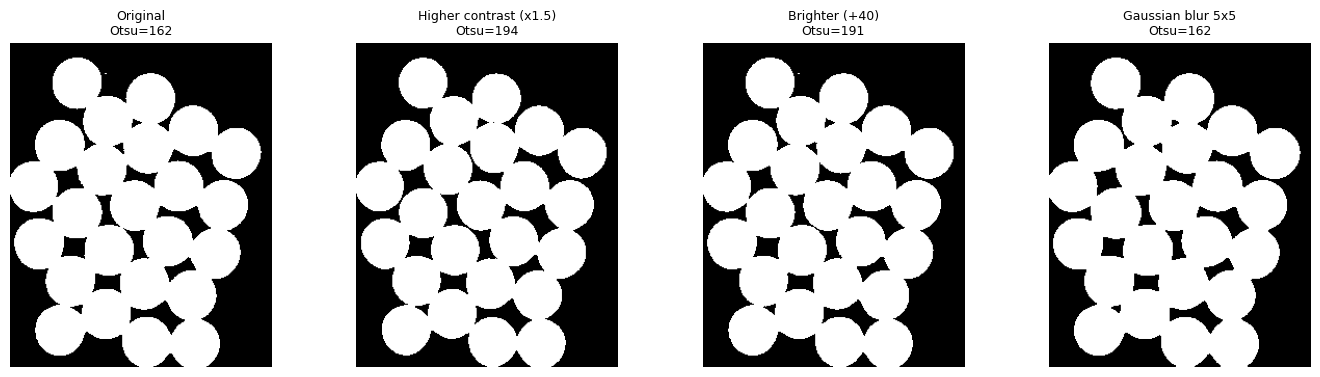

In [8]:
# Repeat after changing contrast / preprocessing slightly and compare the Otsu thresholds
versions = {
    'Original': gray,
    'Higher contrast (x1.5)': cv2.convertScaleAbs(gray, alpha=1.5, beta=0),
    'Brighter (+40)': cv2.convertScaleAbs(gray, alpha=1, beta=40),
    'Gaussian blur 5x5': cv2.GaussianBlur(gray, (5, 5), 0),
}
imgs, titles = [], []
for name, g in versions.items():
    t, m = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    print(f'{name:25} -> Otsu threshold = {t:.0f}')
    imgs.append(m); titles.append(f'{name}\nOtsu={t:.0f}')
show(imgs, titles, 'task3_compare.png')

**Observation:** Otsu picked **162** automatically (the valley between the dark coin peak and the bright background peak). After increasing contrast / brightness it moved to **194 / 191**, while blur kept it at 162. The threshold *changes with the image*, but the coins mask stays about the same.

**Answer – why is Otsu useful when the programmer does not know the threshold beforehand?**
Otsu analyses the histogram, tries all possible thresholds and chooses the one that best separates the two classes (object / background) by maximising the between-class variance. So no manual trial-and-error is needed and it adapts to every new image whose brightness or contrast is different – ideal for a quality-control system.

## Task 4 – Colour segmentation with HSV
HSV separates *colour* (Hue) from brightness (Value), so colour thresholding is easier than using intensity. In OpenCV Hue range is 0–179 (green ≈ 60). Target object: **green smarties**.

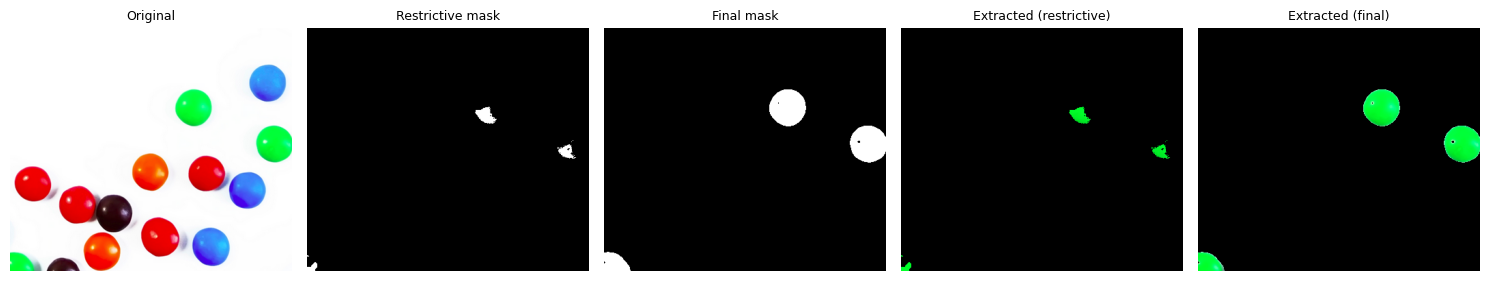

Pixels found  restrictive: 877  final: 5362


In [9]:
img = read('smarties.png')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 1) Too restrictive mask: very narrow hue and only highly saturated/bright pixels
lower_bad, upper_bad = np.array([55, 200, 200]), np.array([65, 255, 255])
mask_bad = cv2.inRange(hsv, lower_bad, upper_bad)

# 2) Final mask: wider hue range + lower saturation/value limits
lower, upper = np.array([40, 80, 40]), np.array([85, 255, 255])
mask = cv2.inRange(hsv, lower, upper)

# Extract the colour from the original image using the mask
extracted_bad = cv2.bitwise_and(img, img, mask=mask_bad)
extracted = cv2.bitwise_and(img, img, mask=mask)

show([img, mask_bad, mask, extracted_bad, extracted],
     ['Original', 'Restrictive mask', 'Final mask', 'Extracted (restrictive)', 'Extracted (final)'],
     'task4_result.png', cols=5, size=3)
print('Pixels found  restrictive:', cv2.countNonZero(mask_bad), ' final:', cv2.countNonZero(mask))

In [10]:
# Experiment with the lower / upper limits
for lo, up in [([50, 80, 40], [70, 255, 255]), ([40, 80, 40], [85, 255, 255]), ([20, 20, 20], [120, 255, 255])]:
    m = cv2.inRange(hsv, np.array(lo), np.array(up))
    print(f'lower={lo} upper={up} -> {cv2.countNonZero(m)} pixels')

lower=[50, 80, 40] upper=[70, 255, 255] -> 4272 pixels
lower=[40, 80, 40] upper=[85, 255, 255] -> 5362 pixels
lower=[20, 20, 20] upper=[120, 255, 255] -> 12369 pixels


**Why the restrictive mask fails:** it only accepts H 55–65, S ≥ 200, V ≥ 200 – the very brightest, most saturated pixels (about 877 pixels = small patches in the middle of the balls). Lighting makes the same green ball lighter at the highlight and darker at the shaded side, so Hue/Saturation/Value vary across the ball. The final mask (H 40–85, S ≥ 80, V ≥ 40) captures the full green balls (5362 pixels, including the cut ball at the bottom-left corner) and still excludes red, orange, blue and brown balls. If the range is made too wide (last experiment, H 20–120) it starts to include blue balls too (12369 pixels).

## Task 5 – Canny edge detection (hysteresis thresholds)
Canny uses two thresholds: gradient **> high** = strong edge (kept); **< low** = rejected; **between** = weak edge, kept only if connected to a strong edge (hysteresis).

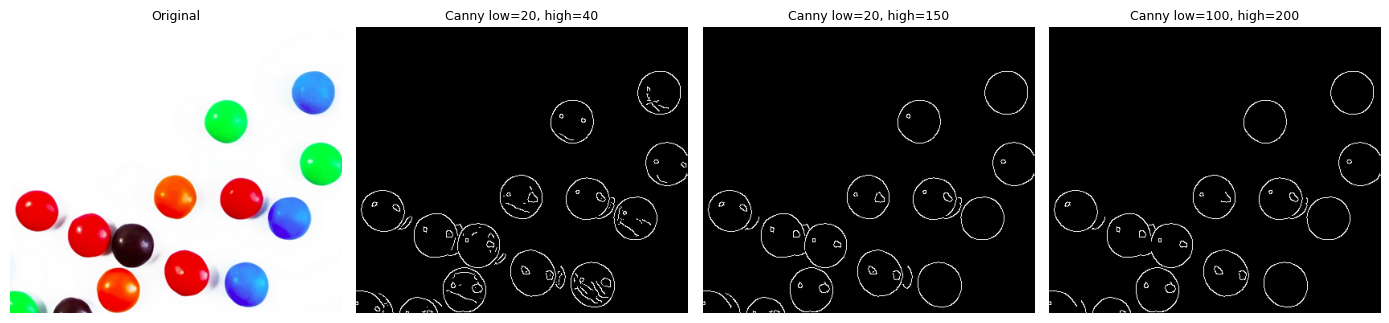

low= 20, high= 40 -> edge pixels = 3945
low= 20, high=150 -> edge pixels = 3114
low=100, high=200 -> edge pixels = 2955


In [11]:
img = read('smarties.png')
gray = cv2.GaussianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), (5, 5), 0)   # blur first to reduce noise

pairs = [(20, 40), (20, 150), (100, 200)]   # (low, high)
edges = [cv2.Canny(gray, lo, hi) for lo, hi in pairs]

show([img] + edges, ['Original'] + [f'Canny low={lo}, high={hi}' for lo, hi in pairs], 'task5_result.png')
for (lo, hi), e in zip(pairs, edges):
    print(f'low={lo:3}, high={hi:3} -> edge pixels = {cv2.countNonZero(e)}')

### Task 5 analysis
* **Strong edges:** the circular outlines of the smarties (huge jump between coloured ball and white background) – present in all three results.
* **Weak edges:** the shadows beside the balls and the shaded part of the ball outline – they appear only when the low threshold is small (20) and they touch strong edges.
* **Missing edges:** with (100, 200) the weak parts of the contours (soft shadow side of balls, light-coloured green/orange balls) are thinner or broken because their gradient is below the thresholds.
* **Unwanted edges:** with (20, 40) many extra edges appear *inside* the balls (highlights, texture, reflections) and extra lines near the bottom – noise, not boundaries (3945 edge pixels vs 2955 for the strictest pair).
* **Effect of the thresholds:** **high** decides which edges are trusted as starting points – a higher value gives fewer, cleaner edges (3945 → 3114 → 2955 pixels) but risks missing real ones. **low** decides how far weak edges are followed from the strong ones – a lower value connects contours but adds noise. Keeping low = 20 and raising high from 40 to 150 removed most inner noise while the outlines stayed connected; (20, 150) is the best compromise here.

## Task 6 – Region growing on a brain MRI
Start from a seed pixel and keep adding the 4 neighbours whose intensity difference from the **seed value** is ≤ threshold.

Seed A (tumour) (160, 120) intensity = 222
Seed B (normal tissue) (120, 215) intensity = 123


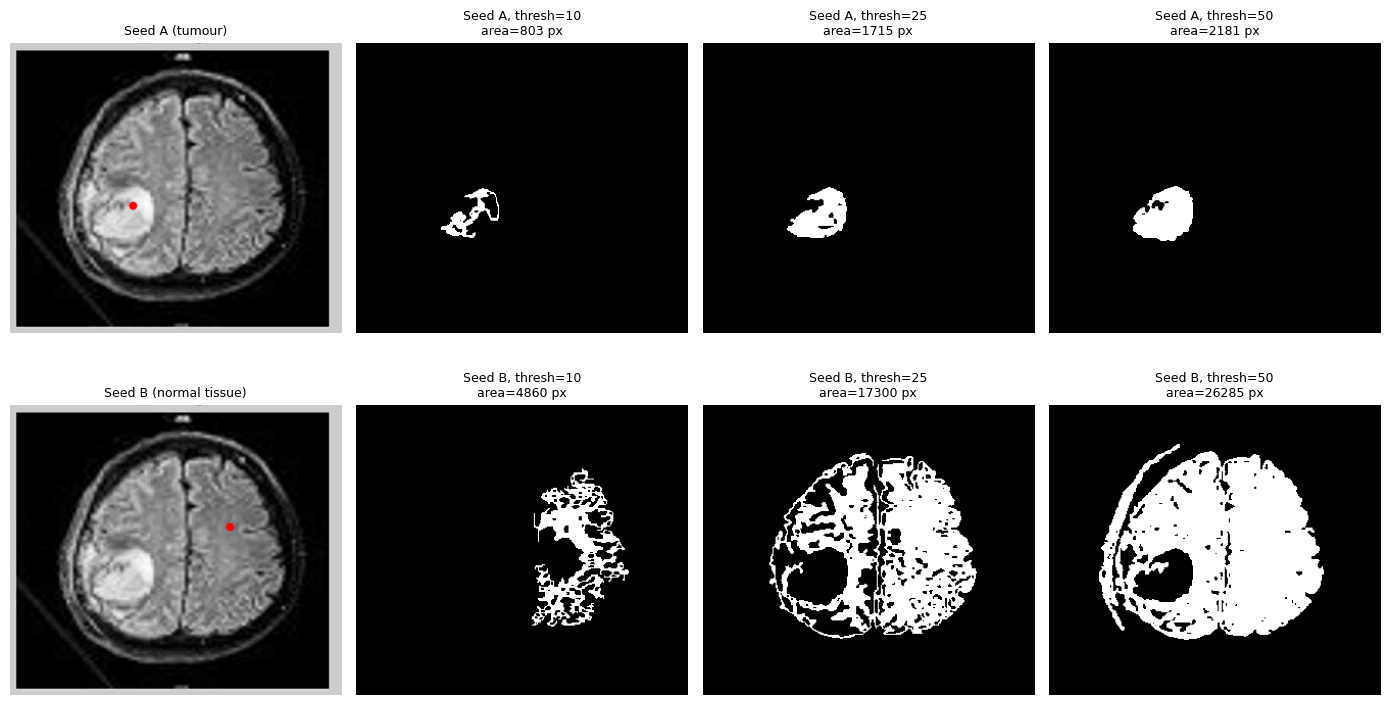

In [12]:
mri_full = read('brain_mri.png', gray=True)
mri = mri_full[40:325, 25:350]     # crop away the figure title / caption of the downloaded picture

def region_growing(img, seed, thresh):
    # seed = (row, col). Returns a binary mask (255 = region)
    mask = np.zeros(img.shape, np.uint8)
    seed_value = int(img[seed])
    queue = deque([seed])
    mask[seed] = 255
    while queue:
        r, c = queue.popleft()
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:        # up, down, left, right
            nr, nc = r + dr, c + dc
            inside = 0 <= nr < img.shape[0] and 0 <= nc < img.shape[1]
            if inside and mask[nr, nc] == 0 and abs(int(img[nr, nc]) - seed_value) <= thresh:
                mask[nr, nc] = 255
                queue.append((nr, nc))
    return mask

seeds = {'Seed A (tumour)': (160, 120), 'Seed B (normal tissue)': (120, 215)}
imgs, titles = [], []
for sname, seed in seeds.items():
    print(sname, seed, 'intensity =', mri[seed])
    marked = cv2.cvtColor(mri, cv2.COLOR_GRAY2BGR); cv2.circle(marked, seed[::-1], 4, (0, 0, 255), -1)
    imgs.append(marked); titles.append(sname)
    for th in [10, 25, 50]:
        m = region_growing(mri, seed, th)
        imgs.append(m); titles.append(f'{sname[:6]}, thresh={th}\narea={cv2.countNonZero(m)} px')
show(imgs, titles, 'task6_result.png', cols=4)

**Parameters:** 4-neighbour growing, thresholds 10 / 25 / 50, seeds A = bright tumour (intensity ≈ 222), B = normal brain tissue (intensity ≈ 123).

**Observations:** seed A grows only inside the bright lesion (803 → 1715 → 2181 px) because the surrounding tissue is much darker. Seed B at thresholds 25 and 50 spreads to a huge part of the brain (17 300 and 26 285 px) and even leaks to the left hemisphere, because the tissue intensities overlap.

**Why can changing the seed point change the final region?** Region growing compares every neighbour with the *seed's intensity*, so the seed decides what "similar" means. A seed inside the tumour accepts only bright pixels; a seed in normal tissue accepts the mid-grey pixels that cover most of the brain. A seed on a noisy / dark pixel gives a bad reference value. Also the region can only grow through connected pixels, so a different start can be blocked by edges. A larger threshold makes the region leak into other structures, a smaller one gives a small, fragmented region.

## Task 7 – Marker-based watershed (separate touching coins)
Pipeline: preprocessing → threshold → noise removal → sure background → distance transform → sure foreground → unknown region → markers → watershed → boundaries.

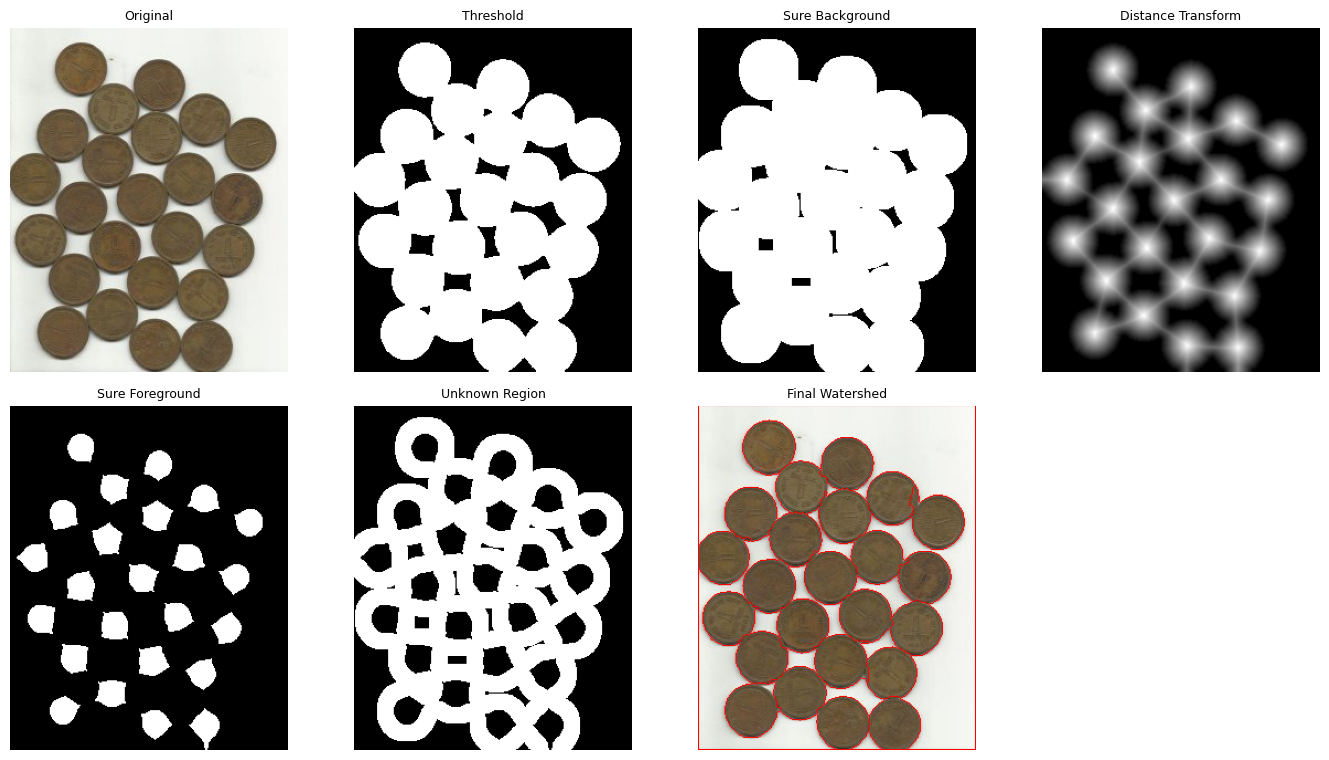

Foreground markers: 24 | separated coin regions: 24
Connected regions in plain threshold: 1


In [13]:
def watershed_pipeline(img, dist_ratio=0.5):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)                                   # 1. preprocessing
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)   # 2. thresholding
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)   # 3. noise removal
    sure_bg = cv2.dilate(opening, kernel, iterations=3)                        # 4. sure background
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)                      # 5. distance transform
    _, sure_fg = cv2.threshold(dist, dist_ratio * dist.max(), 255, 0)          # 6. sure foreground
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)                                   # 7. unknown region
    n_markers, markers = cv2.connectedComponents(sure_fg)                      # 8. marker labelling
    markers = markers + 1            # background becomes 1 (not 0)
    markers[unknown == 255] = 0      # 0 = "unknown", watershed will decide these pixels
    result = img.copy()
    markers = cv2.watershed(result, markers)                                   # 9. watershed
    result[markers == -1] = (0, 0, 255)                                        # 10. boundaries in red
    n_regions = len(np.unique(markers)) - 2      # remove label -1 (boundary) and 1 (background)
    return dict(thresh=thresh, sure_bg=sure_bg, dist=dist, sure_fg=sure_fg, unknown=unknown,
                result=result, n_fg=n_markers - 1, n_regions=n_regions)

img = read('coins.jpg')
r = watershed_pipeline(img, 0.5)
dist_show = cv2.normalize(r['dist'], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

show([img, r['thresh'], r['sure_bg'], dist_show, r['sure_fg'], r['unknown'], r['result']],
     ['Original', 'Threshold', 'Sure Background', 'Distance Transform', 'Sure Foreground', 'Unknown Region', 'Final Watershed'],
     'task7_result.png', cols=4)
cv2.imwrite('Output/task7_final.png', r['result'])
print('Foreground markers:', r['n_fg'], '| separated coin regions:', r['n_regions'])
print('Connected regions in plain threshold:', cv2.connectedComponents(r['thresh'])[0] - 1)

**Visual inspection:** the plain Otsu threshold gives **one** connected white region (printed: 1 connected region) for ~24 touching coins, so counting regions directly gives 1. After the distance transform every coin has its own bright centre → 24 sure-foreground markers → watershed draws red lines between touching coins and gives **24 separated regions**. Touching coins are separated correctly (a few boundaries are slightly jagged where two coins overlap).

**Parameters:** Gaussian blur 5×5 (reduce noise), Otsu threshold, opening 3×3 × 2 iterations (remove small noise), dilation × 3 (sure background), distance threshold = 0.5 × max distance (sure foreground).

## Task 8 – Tuning the distance-transform threshold

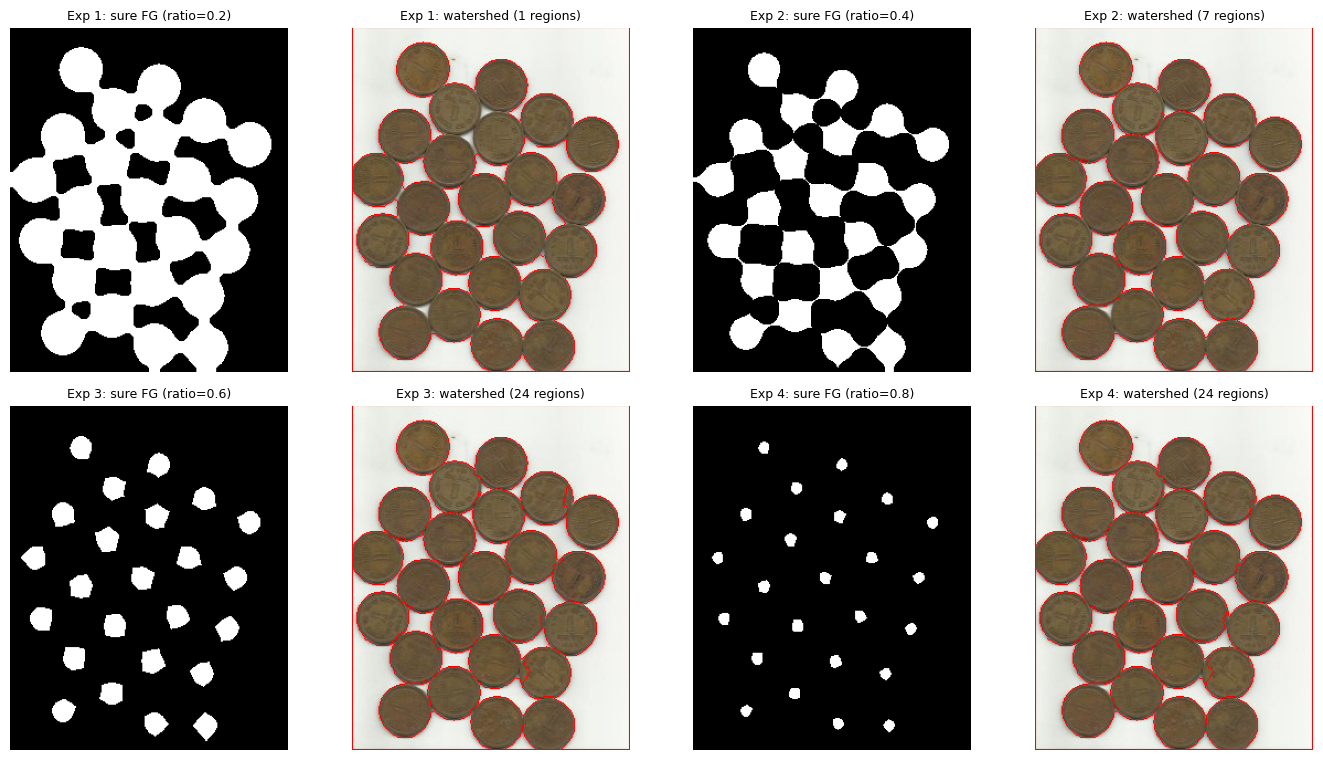

Experiment  Dist threshold  FG markers  Regions
         1       0.2 x max           1        1
         2       0.4 x max           7        7
         3       0.6 x max          24       24
         4       0.8 x max          24       24


In [14]:
rows = []
imgs, titles = [], []
for i, ratio in enumerate([0.2, 0.4, 0.6, 0.8], 1):
    r = watershed_pipeline(img, ratio)
    rows.append((i, ratio, r['n_fg'], r['n_regions']))
    imgs += [r['sure_fg'], r['result']]
    titles += [f'Exp {i}: sure FG (ratio={ratio})', f'Exp {i}: watershed ({r["n_regions"]} regions)']
show(imgs, titles, 'task8_result.png', cols=4)

print(f"{'Experiment':>10} {'Dist threshold':>15} {'FG markers':>11} {'Regions':>8}")
for row in rows: print(f'{row[0]:>10} {row[1]:>9} x max {row[2]:>11} {row[3]:>8}')

### Task 8 results table

| Experiment | Distance threshold | Foreground markers | Regions | Observed result |
|---|---|---|---|---|
| 1 | 0.2 × max | 1 | 1 | Sure foreground is too large – all coins are connected into one marker → **everything merged** |
| 2 | 0.4 × max | 7 | 7 | Markers still merge groups of touching coins → **many coins merged** |
| 3 | 0.6 × max | 24 | 24 | One marker per coin → **all coins separated correctly** |
| 4 | 0.8 × max | 24 | 24 | Markers become very small but still 1 per coin; separated, but risk of losing small / non-circular coins and a slightly jagged split in a couple of places |

**Best parameter range:** about **0.6 – 0.8 × max distance** (0.6 is the safest). Too low → touching objects share a marker (under-segmentation / merged); too high → markers shrink and, for smaller or irregular objects, can disappear or split one object into several (over-segmentation).

## Task 9 – K-Means colour segmentation
Workflow: reshape pixels to (N, 3) → float32 → `cv2.kmeans` → centers → rebuild image.

  K  unique colours  mean abs diff from original
  -           28661                            0
  2               2                         17.4
    cluster colours (BGR): [[143, 148, 180], [60, 67, 90]]
  4               4                          9.8
    cluster colours (BGR): [[70, 84, 116], [115, 124, 166], [53, 56, 75], [182, 182, 200]]


  6               6                          7.8
    cluster colours (BGR): [[83, 99, 134], [61, 72, 101], [189, 190, 207], [114, 129, 190], [52, 54, 71], [151, 143, 156]]


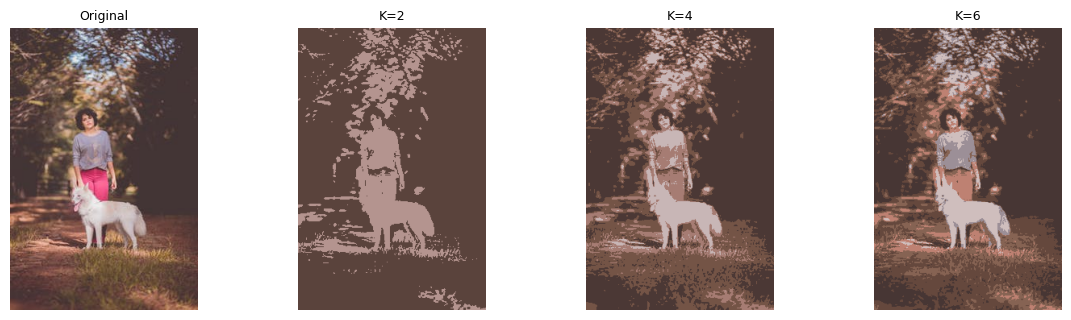

In [15]:
img = read('dog.jpeg')
pixels = img.reshape(-1, 3)            # every pixel = one feature vector [B, G, R]
pixels = np.float32(pixels)            # kmeans needs float32
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)

imgs, titles = [img], ['Original']
print(f"{'K':>3} {'unique colours':>15} {'mean abs diff from original':>28}")
print(f"{'-':>3} {len(np.unique(pixels, axis=0)):>15} {0:>28}")
for K in [2, 4, 6]:
    _, labels, centers = cv2.kmeans(pixels, K, None, criteria, 5, cv2.KMEANS_PP_CENTERS)
    centers = np.uint8(centers)                         # cluster centres = the K colours
    seg = centers[labels.flatten()].reshape(img.shape)  # replace every pixel by its centre colour
    imgs.append(seg); titles.append(f'K={K}')
    diff = np.abs(seg.astype(int) - img.astype(int)).mean()
    print(f'{K:>3} {len(np.unique(centers, axis=0)):>15} {diff:>28.1f}')
    print('    cluster colours (BGR):', centers.tolist())
show(imgs, titles, 'task9_result.png', size=3)

### Task 9 observations

| K | Visual difference from original | Colour simplification | Major regions represented |
|---|---|---|---|
| 2 | Very large – only two tones, many details lost (mean abs diff ≈ 17.4) | Maximum (28 661 colours → 2) | dark trees / shadow vs light areas (dog, sweater, path, leaves) |
| 4 | Medium – scene recognisable, flat posterised look (≈ 9.8) | High (→ 4) | dark background, brown ground, mid-tone trees/trousers, bright dog + sweater |
| 6 | Smallest – closest to original (≈ 7.8) | Lower (→ 6) | also separates the sweater (bluish-grey), trousers and sunlit leaves |

Note: the pink trousers are not a separate cluster even at K = 6 – they get merged with brown/ground colours, because K-Means groups by overall colour distance (the dark/brown pixels dominate). More clusters → less error but less simplification.

## Task 10 – Segmentation system for an unknown image
Image: **dog.jpeg** (natural scene: dark trees, brown ground, white dog, person with pink trousers). Methods: **Otsu thresholding**, **HSV colour thresholding**, **K-Means**.

Otsu threshold: 113.0


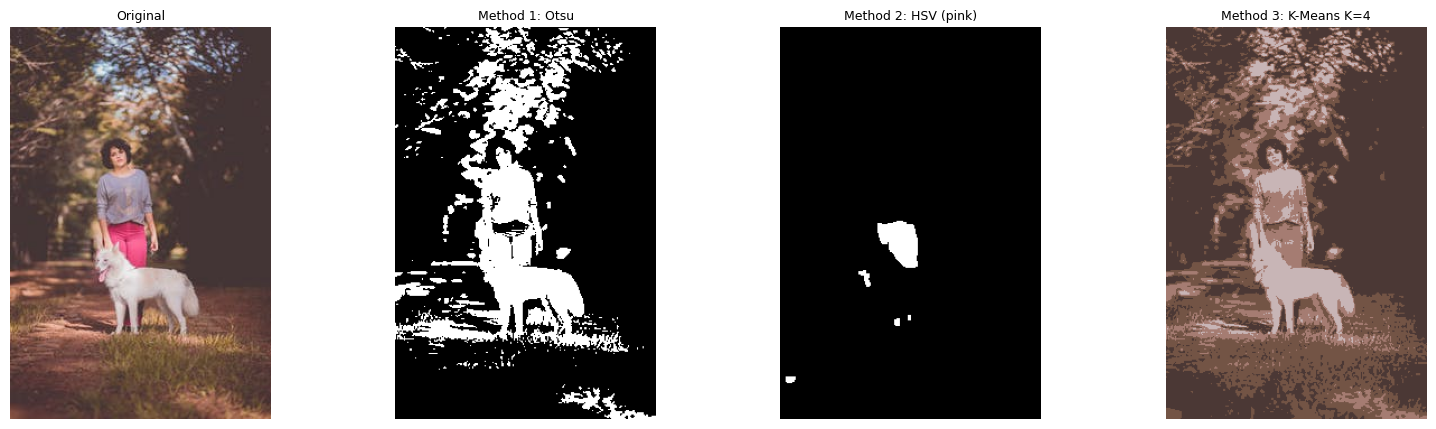

In [16]:
img = read('dog.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Method 1: Otsu (assumes 2 intensity classes -> dark / bright)
t, m1 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print('Otsu threshold:', t)

# Method 2: HSV colour (select the pink trousers)
m2 = cv2.inRange(hsv, np.array([150, 80, 80]), np.array([179, 255, 255]))
m2 = cv2.morphologyEx(m2, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))   # remove small noise

# Method 3: K-Means with K=4 colours
pix = np.float32(img.reshape(-1, 3))
_, labels, centers = cv2.kmeans(pix, 4, None, (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0), 5, cv2.KMEANS_PP_CENTERS)
m3 = np.uint8(centers)[labels.flatten()].reshape(img.shape)

show([img, m1, m2, m3], ['Original', 'Method 1: Otsu', 'Method 2: HSV (pink)', 'Method 3: K-Means K=4'], 'task10_result.png', size=4)

### Method analysis

| | Assumption about the image | Region it identifies successfully | What it segments incorrectly | Parameter with greatest effect |
|---|---|---|---|---|
| **Otsu** | Histogram has two intensity classes (dark / bright) | The bright white dog, the sweater and the sunlit patches | Merges dog with sunlit grass / path / sky patches; dark-but-different objects (hair, trousers) fall into the background | None (automatic) – result depends on preprocessing (blur / contrast), which changes the threshold (113 here) |
| **HSV colour** | The target has a distinct hue range | The pink trousers cleanly | Nothing else (dog, person, background are ignored); a few small pink-ish specks on the ground / the dog's tongue | Hue limits (lower / upper H) and minimum saturation |
| **K-Means (K = 4)** | The image is made of K dominant colours | Main areas: dark background, brown ground, mid-tone, and the bright dog + sweater | The pink trousers are merged with ground colours; sunlit leaves and dog share a cluster | K (number of clusters) |

### Technical conclusion
For this complex natural image **K-Means (K = 4)** produced the most meaningful *overall* regions: it separates the white dog and sweater, the brown path and the dark trees at the same time, because the scene is made of a few dominant colour groups and clustering uses all three colour channels together. Otsu only uses one intensity cut-off, so it merged the dog with every other bright area (sunlit patches, grass), which does not match the actual objects. HSV thresholding was the most precise method but only for **one** object (pink trousers) – it works because that object has a unique hue that no other object has. So no single method segments every object: K-Means is best for the whole scene, HSV is best when the target colour is known.